<a href="https://colab.research.google.com/github/Zvonimir-Staubringer/EMIBU-web-projekt/blob/master/SU_LV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Konvolucijske neuronske mreže (CNN)

Osnovni pojmovi kod konvolucijskih neuronskih mreža:
 - Konvolucija
 - Sažimanje (pooling)

In [1]:
## Importing useful libraries
import os
import math
import numpy as np
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torchvision.transforms as transforms
import torchvision

import matplotlib.pyplot as plt
from imageio.v2 import imread
%matplotlib inline

from tqdm.notebook import tqdm

In [2]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device", device)

Device cuda


### Konvolucija*

Konvolucija u neuronskim mrežama je matematička operacija koja prima dva skupa podataka, ulazni skup (sliku ili značajke) i filter (kernel).

Filter je 2D matrica realnih brojeva. Filter se primjenjuje na gornji lijevi kut ulaznog skupa, pomiče se određeni broj elemenata u desno, to se ponavlja do kraja retka, pa se pomiče prema dolje itd. Filter se primjenjuje na način da se svaki element filtera pomnoži s *preklopljenim* elementom ulaznog skupa te se tako dobiveni brojevi zbroje. Taj novi broj je jedan element izlaznog skupa podataka. Filter se uči za vrijeme treniranja konvolucijske neuronske mreže.

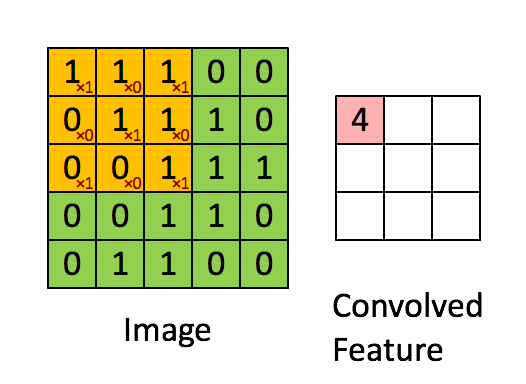






**Ovdje se radi o 2D konvoluciji, ali slični pojmovi i operacije se mogu primijeniti i kod 3D konvolucija*.

Postoje razni parametri konvolucijskih slojeva u neuronskim mrežama. U nastavku su nabrojani neki od njih, a o ostalima možete pročitati [ovdje](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html).

- broj ulaznih kanala (*in_channels*) - broj kanala ulazne slike/značajki, primjerice 3 za slučaj RGB slike
- broj izlaznih kanala (*out_channels*)
- veličina kernela/filtera (*kernel_size*) - dimenzije kernela
- *stride* - broj piksela koliko se kernel pomiče pri konvoluciji
- *padding* - broj piksela koji se dodaju na rub ulaznih podataka

Probajmo primijeniti konvoluciju na nekakvu sliku.

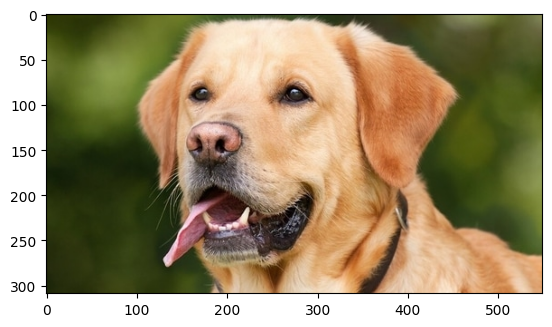

In [3]:
link = "https://www.hindustantimes.com/ht-img/img/2023/08/25/550x309/international_dog_day_1692974397743_1692974414085.jpg"
input_image = imread(link)
plt.imshow(input_image)
plt.show()

In [4]:
transform = transforms.Compose([
    transforms.ToTensor()
])
input_tensor = transform(input_image)

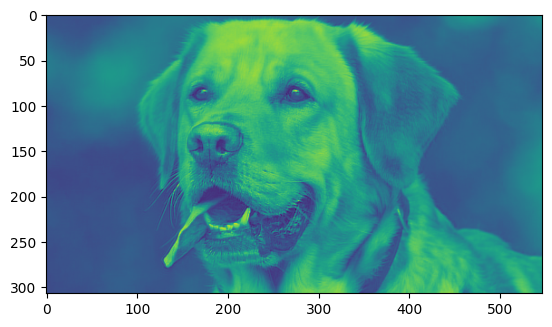

In [5]:
convolution = nn.Conv2d(3, 1, 3)
out = convolution(input_tensor)
out_image = out.detach().numpy().transpose(1, 2, 0)
plt.imshow(out_image)
plt.show()

Gore je prikazan izlaz iz konvolucije nasumičnih filtera, možemo ispisati te filtere. Također možemo i napraviti svoje filtere te ih primijeniti na ulaznu sliku.

In [6]:
convolution.weight

Parameter containing:
tensor([[[[-0.1795, -0.0169,  0.1513],
          [ 0.0873, -0.0074, -0.0458],
          [-0.1207, -0.0609,  0.0927]],

         [[ 0.1904,  0.0176, -0.1793],
          [ 0.1873, -0.0113, -0.0023],
          [ 0.1553, -0.1299,  0.1261]],

         [[ 0.0015, -0.0729, -0.0371],
          [ 0.0784,  0.1802,  0.1075],
          [ 0.1306, -0.0719, -0.1307]]]], requires_grad=True)

In [7]:
our_kernel = [[[[-1, 0, 1],
                [-2, 0, 2],
                [-1, 0, 1]],
               [[-1, 0, 1],
                [-2, 0, 2],
                [-1, 0, 1]],
               [[-1, 0, 1],
                [-2, 0, 2],
                [-1, 0, 1]]]]
our_kernel = nn.Parameter(torch.Tensor(our_kernel))
convolution.weight = our_kernel

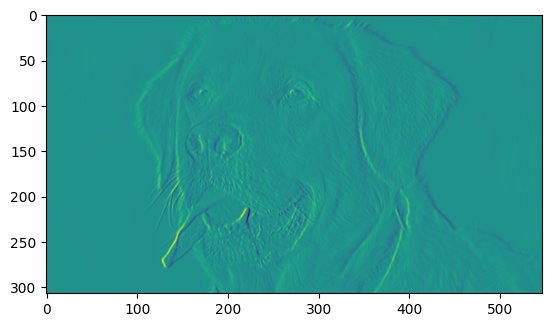

In [8]:
out = convolution(input_tensor)
out_image = out.detach().numpy().transpose(1, 2, 0)
plt.imshow(out_image)
plt.show()

Možemo primijetiti da smo pomoću gore definiranog filtera detektirali vertikalne rubove na ulaznoj slici.

### Sažimanje

Sloj sažimanja (*pooling layer*) sažima ulazne podatke te im tako smanjuje dimenzije. Primjenjuje se u konvolucijskim neuronskim mrežama nakon jednog ili više konvolucijskih slojeva. Postoje [razni](https://pytorch.org/docs/stable/nn.html#pooling-layers) načini sažimanja, ali najčešći je [*max pooling*](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html#torch.nn.MaxPool2d).

*Max pooling* jednostavno uzima određeni segment ulazne matrice i bira najveću vrijednost koja se upisuje u izlaznu matricu. *Max pooling* sloj ima nekoliko parametara, a neki od njih su:
 - `kernel_size` - veličina prozora (kernela), može biti jedan broj ili *tuple*
 - `stride` - broj piksela koliko se prozor pomiče, može biti jedan broj ili *tuple*, zadano je da je jednako veličini prozora

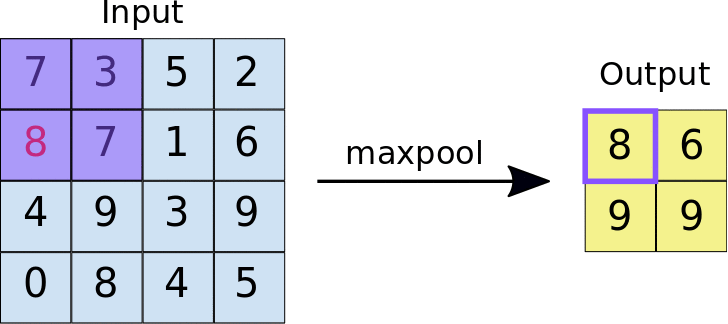

In [9]:
## TODO
## Implement the max pooling layer and use it on the above image of edges
## Check the input and output shapes and how they differ depending on the
## max pooling kernel size

Shape before pooling: torch.Size([1, 307, 547])
Shape after pooling (kernel_size=2): torch.Size([1, 153, 273])


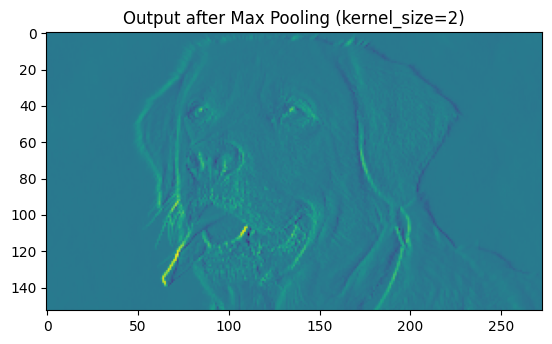

In [10]:
# Define a Max Pooling layer with kernel_size=2
max_pool = nn.MaxPool2d(kernel_size=2)

# Apply max pooling to the output of the convolution
out_pooled = max_pool(out)

print(f"Shape before pooling: {out.shape}")
print(f"Shape after pooling (kernel_size=2): {out_pooled.shape}")

# Visualize the pooled image
out_pooled_image = out_pooled.detach().numpy().transpose(1, 2, 0)
plt.imshow(out_pooled_image)
plt.title("Output after Max Pooling (kernel_size=2)")
plt.show()

### Konvolucijska neuronska mreža

Standardna konvolucijska mreža je kombinacija 3 vrste slojeva:
 - Konvolucijski slojevi
 - Slojevi sažimanja
 - Potpuno povezani slojevi

Naravno, primjenjuju se razne aktivacijske funkcije nakon konvolucijskih i potpuno povezanih slojeva. Također se koriste i drugi slojevi, koje ćemo odraditi u budućim LV-ovima, povratne veze itd.

CNN-ovi su često izgrađeni na način da se nizaju konvolucijski slojevi popraćeni slojem sažimanja, zatim se opet nizaju konvolucijski slojevi popraćeni slojem sažimanja, što se ponavlja određeni broj puta te se na kraju izlaz iz posljednjeg sloja sažimanja provlači kroz potpuno povezane slojeve. Primjer ovakve jedne mreže (VGG-16) je prikazan na slici. Na ovom primjeru je jasno vidljivo kako se prve dvije dimenzije podataka smanjuju prolaskom kroz mrežu, a treća dimenzija, broj kanala, se povećava. Također je važno naglasiti da je, prije dodavanja potpuno povezanih slojeva, potrebno dodati [sloj za izravnavanje (*flatten*)](https://pytorch.org/docs/stable/generated/torch.nn.Flatten.html).

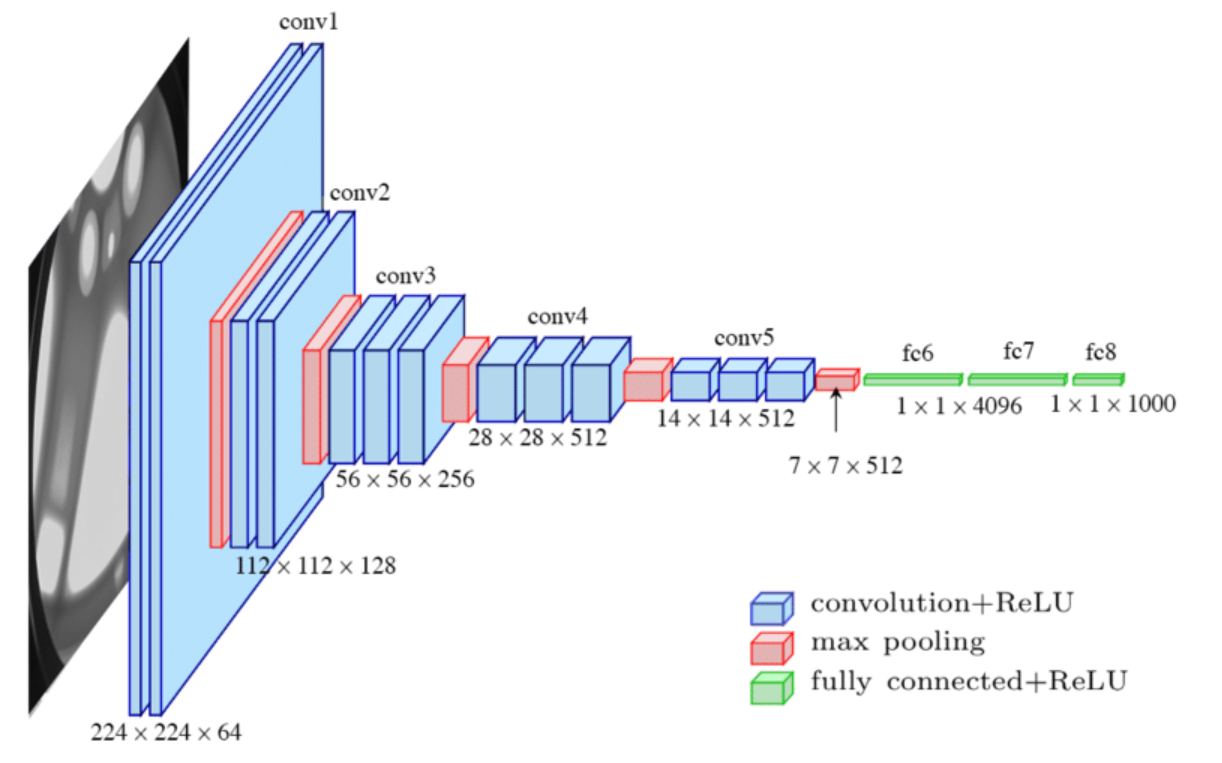

## Zadatak

Potrebno je izraditi i istrenirati konvolucijsku neuronsku mrežu na CIFAR-10 podatkovnom skupu.

CIFAR-10 je podatkovni skup koji se sastoji od 60000 slika u boji veličine 32x32. Svaka od ovih slika je klasificirana u jednu od 10 klasa. Podatkovni skup je podijeljen na skup za treniranje (50000 slika) i skup za testiranje (10000). Potrebno je skup za treniranje dodatno podijeliti na skup za treniranje (40000) i skup za validaciju (10000). Ovo možete učiniti pomoću sljedeće naredbe:

`trainset, valset = torch.utils.data.random_split(whole_trainset, [40000, 10000])`

Taj [podatkovni skup](https://pytorch.org/vision/stable/generated/torchvision.datasets.CIFAR10.html) se može vrlo lagano dohvatiti pomoću *torchvision* biblioteke.

In [11]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 512

whole_trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
## TODO
## divide the trainset into trainset and valset
## containing 40000 and 10000 images respectively

trainset, valset = torch.utils.data.random_split(whole_trainset, [40000, 10000])

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:04<00:00, 42.5MB/s]


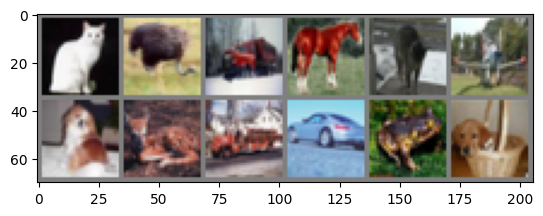

cat   bird  truck horse cat   plane dog   deer  truck car   frog  dog  


In [12]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

images = images[:12]
labels = labels[:12]

# show images
imshow(torchvision.utils.make_grid(images, nrow=6))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(12)))

#### Mreža

Implementirajte neuronsku mrežu koja se sastoji od tri konvolucijska sloja, svaki od kojih je popraćen ReLU aktivacijskom funckijom i *max pooling* slojem. Za *max pooling* koristite kernel veličine 2x2. Brojeve filtera u konvolucijskim slojevima odaberite proizvoljno (nemojte odabrati prevelike brojeve za ovaj zadatak).

Svi konvolucijski slojevi koriste sljedeće parametre:
 - Veličina filtera (kernela): 3x3
 - *stride*: 1
 - *padding*: 'same'

Nakon konvolucijskih slojeva, dodajte tri potpuno povezana sloja s proizvoljnim brojem neurona. Napomena: Posljednji sloj treba imati 10 izlaza za 10 klasa i ne treba imati aktivacijsku funkciju.

Mreža će se koristiti za rad na podatkovnom skupu koji sadrži slike veličine 32x32, stoga prilagodite potpuno povezane slojeve tim dimenzijama.



In [13]:
## TODO
## Implement the convolutional neural network

import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):

    def __init__(self):
        super().__init__()
        # Convolutional Block 1: Input 3x32x32 -> Output 32x32x32 -> Pool 32x16x16
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding='same')
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Convolutional Block 2: Input 32x16x16 -> Output 64x16x16 -> Pool 64x8x8
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding='same')
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Convolutional Block 3: Input 64x8x8 -> Output 128x8x8 -> Pool 128x4x4
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding='same')
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Calculate flattened size for the first fully connected layer
        # The image size starts at 32x32. Each MaxPool2d with kernel_size=2 and stride=2 halves the dimensions.
        # 32 -> 16 -> 8 -> 4
        # The last conv layer has 128 output channels.
        self.flattened_size = 128 * 4 * 4 # 128 filters, 4x4 spatial dimensions

        # Fully Connected Layers
        self.fc1 = nn.Linear(self.flattened_size, 512) # Arbitrary number of neurons
        self.fc2 = nn.Linear(512, 256) # Arbitrary number of neurons
        self.fc3 = nn.Linear(256, 10) # 10 output classes, no activation for CrossEntropyLoss

    def forward(self, x):
        # Convolutional Block 1
        x = self.pool1(F.relu(self.conv1(x)))
        # Convolutional Block 2
        x = self.pool2(F.relu(self.conv2(x)))
        # Convolutional Block 3
        x = self.pool3(F.relu(self.conv3(x)))

        # Flatten the output for the fully connected layers
        x = torch.flatten(x, 1) # Flatten all dimensions except batch dimension (dimension 0)

        # Fully Connected Layers
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x) # No activation for the last layer (CrossEntropyLoss expects raw logits)
        return x

Nakon što ste definirali mrežu i podatkovne skupove za treniranje i testiranje, vrijeme je za treniranje mreže. Primijenite znanja stečena u prvoj laboratorijskoj vježbi kako biste istrenirali VGG-16 neuronsku mrežu na CIFAR-10 podatkovnom skupu. Za funkciju gubitka koristite [gubitak unakrsne entropije (*cross-entropy loss*)](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html).

In [21]:
## TODO
## Define the loss function and the optimizer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNN().to(device)

loss_module = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

Za razliku od prve vježbe, ovdje je potrebno dodati i kontinuirano praćenje vrijednosti funkcije gubitka na skupovima za treniranje i validaciju po epohama. Kako biste ovo postigli, možete kumulativno zbrajati vrijednost funkcije gubitka u svakoj iteraciji treniranja.

Prilikom treninga, na kraju svake epohe izračunajte točnost modela na skupovima za treniranje i validaciju. Hint: Koristite istu funkciju za izračun vrijednosti funkcije gubitka (loss) i za točnost na validacijskom skupu.

Ove vrijednosti možete odmah ispisivati na ekran, ali je bitno da ih spremite u varijable kojima ćete moći poslije pristupiti zbog vizualizacije i analize (možete te varijable vratiti kao izlaze iz funkcije za treniranje).

Koristite tqdm za praćenje tijeka treniranja za svaku epohu posebno (za razliku od praćenja tijeka treniranja za sve epohe zajedno). To možete učiniti na sljedeći način:

`for data_inputs, data_labels in tqdm(data_loader, 'Epoch %d'%(epoch + 1)):`,

gdje je `epoch` broj epohe za koju se ispisuje tijek.


In [15]:
def eval_model(model, data_loader, loss_module):
    model.eval() # Set model to eval mode
    true_preds, num_preds = 0., 0.
    total_loss = 0.0

    ## TODO
    ## Calculate loss for the whole dataset

    with torch.no_grad(): # Deactivate gradients for the following code
        for data_inputs, data_labels in data_loader:

            # Determine prediction of model on dev set
            data_inputs, data_labels = data_inputs.to(device), data_labels.to(device)
            preds = model(data_inputs)

            # Calculate loss for the batch
            loss = loss_module(preds, data_labels)
            total_loss += loss.item() * data_inputs.size(0) # Accumulate batch loss, weighted by batch size

            _, pred_labels = torch.max(preds.data, dim=1) # Binarize predictions to 0 and 1

            # Keep records of predictions for the accuracy metric (true_preds=TP+TN, num_preds=TP+TN+FP+FN)
            true_preds += (pred_labels == data_labels).sum().item()
            num_preds += data_labels.shape[0]

    acc = true_preds / num_preds
    avg_loss = total_loss / num_preds
    print(f"Accuracy of the model: {100.0*acc:4.2f}% | Loss: {avg_loss:4.4f}")
    ## TODO
    ## Return the accuracy and the loss
    return acc, avg_loss

In [16]:
## TODO
## Train the network
def train_model(model, optimizer, train_data_loader, val_data_loader, loss_module, num_epochs=100):
    # Set model to train mode
    model.train()

    # Lists to store metrics for visualization
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    # Training loop
    for epoch in range(num_epochs):
        # Loop over the training data
        total_train_loss = 0.0
        num_train_samples = 0

        for data_inputs, data_labels in tqdm(train_data_loader, 'Epoch %d'%(epoch + 1)):

            ## Step 1: Move input data to device
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.to(device)

            ## Step 2: Run the model on the input data
            preds = model(data_inputs)

            ## Step 3: Calculate the loss
            loss = loss_module(preds, data_labels)
            total_train_loss += loss.item() * data_inputs.size(0)
            num_train_samples += data_inputs.size(0)

            ## Step 4: Perform backpropagation
            optimizer.zero_grad()
            # Perform backpropagation
            loss.backward()

            ## Step 5: Update the parameters
            optimizer.step()

        ## TODO
        ## Calculate loss and accuracy for both datasets
        ## Store the accuracies and losses for both datasets
        # Calculate training metrics
        train_acc, avg_train_loss = eval_model(model, train_data_loader, loss_module)
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_acc)

        # Calculate validation metrics
        val_acc, avg_val_loss = eval_model(model, val_data_loader, loss_module)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {avg_train_loss:.4f}, Train Acc: {100.0*train_acc:.2f}% | Val Loss: {avg_val_loss:.4f}, Val Acc: {100.0*val_acc:.2f}%")

        model.train() # Set model back to train mode

    return train_losses, val_losses, train_accuracies, val_accuracies

In [17]:
def visualize_training(train_loss, val_loss, train_acc, val_acc):
  plt.figure(figsize=[4,3])
  plt.plot(train_loss,'r',linewidth=1.0)
  plt.plot(val_loss,'b',linewidth=1.0)
  plt.legend(['Training loss', 'Validation Loss'],fontsize=8)
  plt.xlabel('Epochs ',fontsize=16)
  plt.ylabel('Loss',fontsize=16)
  plt.title('Loss Curves',fontsize=16)

  # Accuracy Curves
  plt.figure(figsize=[4,3])
  plt.plot(train_acc,'r',linewidth=1.0)
  plt.plot(val_acc,'b',linewidth=1.0)
  plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=8)
  plt.xlabel('Epochs ',fontsize=16)
  plt.ylabel('Accuracy',fontsize=16)
  plt.title('Accuracy Curves',fontsize=16)

Epoch 1:   0%|          | 0/79 [00:00<?, ?it/s]

Accuracy of the model: 43.59% | Loss: 1.5370
Accuracy of the model: 44.32% | Loss: 1.5217
Epoch 1/20 - Train Loss: 1.5370, Train Acc: 43.59% | Val Loss: 1.5217, Val Acc: 44.32%


Epoch 2:   0%|          | 0/79 [00:00<?, ?it/s]

Accuracy of the model: 53.24% | Loss: 1.2950
Accuracy of the model: 53.73% | Loss: 1.3065
Epoch 2/20 - Train Loss: 1.2950, Train Acc: 53.24% | Val Loss: 1.3065, Val Acc: 53.73%


Epoch 3:   0%|          | 0/79 [00:00<?, ?it/s]

...

Accuracy of the model: 88.77% | Loss: 0.3147
Accuracy of the model: 66.64% | Loss: 1.5252
Epoch 18/20 - Train Loss: 0.3147, Train Acc: 88.77% | Val Loss: 1.5252, Val Acc: 66.64%


Epoch 19:   0%|          | 0/79 [00:00<?, ?it/s]

Accuracy of the model: 91.42% | Loss: 0.2423
Accuracy of the model: 66.51% | Loss: 1.7056
Epoch 19/20 - Train Loss: 0.2423, Train Acc: 91.42% | Val Loss: 1.7056, Val Acc: 66.51%


Epoch 20:   0%|          | 0/79 [00:00<?, ?it/s]

Accuracy of the model: 93.48% | Loss: 0.1828
Accuracy of the model: 66.25% | Loss: 1.5988
Epoch 20/20 - Train Loss: 0.1828, Train Acc: 93.48% | Val Loss: 1.5988, Val Acc: 66.25%


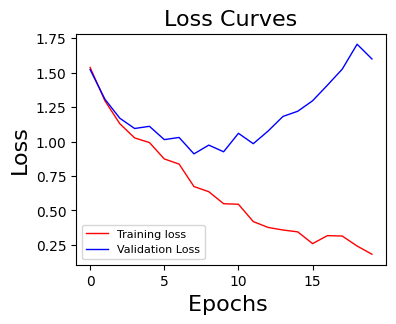

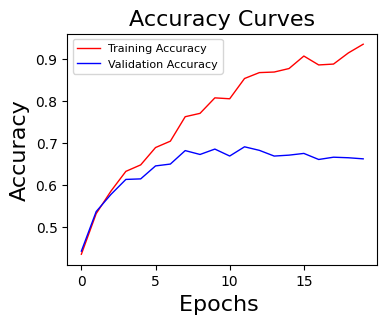

In [22]:
train_losses, val_losses, train_accuracies, val_accuracies = train_model(model, optimizer, trainloader, valloader, loss_module, num_epochs=20)
visualize_training(train_losses, val_losses, train_accuracies, val_accuracies)

Istestirajte istreniranu neuronsku mrežu na skupu za testiranje, ispišite ukupnu točnost i vizualizirajte neke od predikcija.

In [19]:
## TODO
## Test the network

print("Evaluating on test dataset:")
test_acc, avg_test_loss = eval_model(model, testloader, loss_module)
print(f"Test Accuracy: {100.0*test_acc:.2f}% | Test Loss: {avg_test_loss:.4f}")

Evaluating on test dataset:
Accuracy of the model: 72.33% | Loss: 0.8034
Test Accuracy: 72.33% | Test Loss: 0.8034


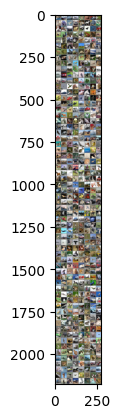

GroundTruth:  cat   ship  ship  plane frog  frog  car   frog  cat   car   plane truck dog   horse truck ship  dog   horse ship  frog  horse plane deer  truck dog   bird  deer  plane truck frog  frog  dog   deer  dog   truck bird  deer  car   truck dog   deer  frog  dog   frog  plane truck cat   truck horse frog  truck ship  plane cat   ship  ship  horse horse deer  frog  horse cat   frog  cat   frog  bird  car   bird  cat   horse bird  frog  ship  ship  plane bird  truck cat   cat   ship  ship  car   car   horse bird  dog   bird  horse ship  truck plane cat   ship  frog  deer  frog  frog  plane plane horse deer  dog   frog  cat   car   car   cat   frog  ship  horse deer  plane frog  bird  car   cat   plane deer  bird  horse ship  cat   car   bird  ship  plane ship  cat   dog   bird  deer  car   ship  truck car   bird  truck horse bird  truck frog  dog   frog  cat   ship  horse frog  bird  dog   bird  ship  truck frog  plane plane dog   bird  truck dog   deer  bird  car   frog  frog  sh

In [20]:
import numpy as np

# Get some random test images
dataiter = iter(testloader)
images, labels = next(dataiter)

# Move images to the device
images = images.to(device)

# Make predictions
outputs = model(images)
_, predicted = torch.max(outputs, 1)

# Unnormalize and show images
imshow(torchvision.utils.make_grid(images.cpu()))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))
print('Predicted:   ', ' '.join(f'{classes[predicted[j]]:5s}' for j in range(batch_size)))